⏳ Loading target dataset: '1) iris.csv'...
⚙️ Executing iterative cluster sweeps (K=1 to K=10) via Elbow Method...
🎯 Training final K-Means architecture targeting K=3 groupings...
📊 Mapping spatial clusters and center coordinates onto scatter grid...


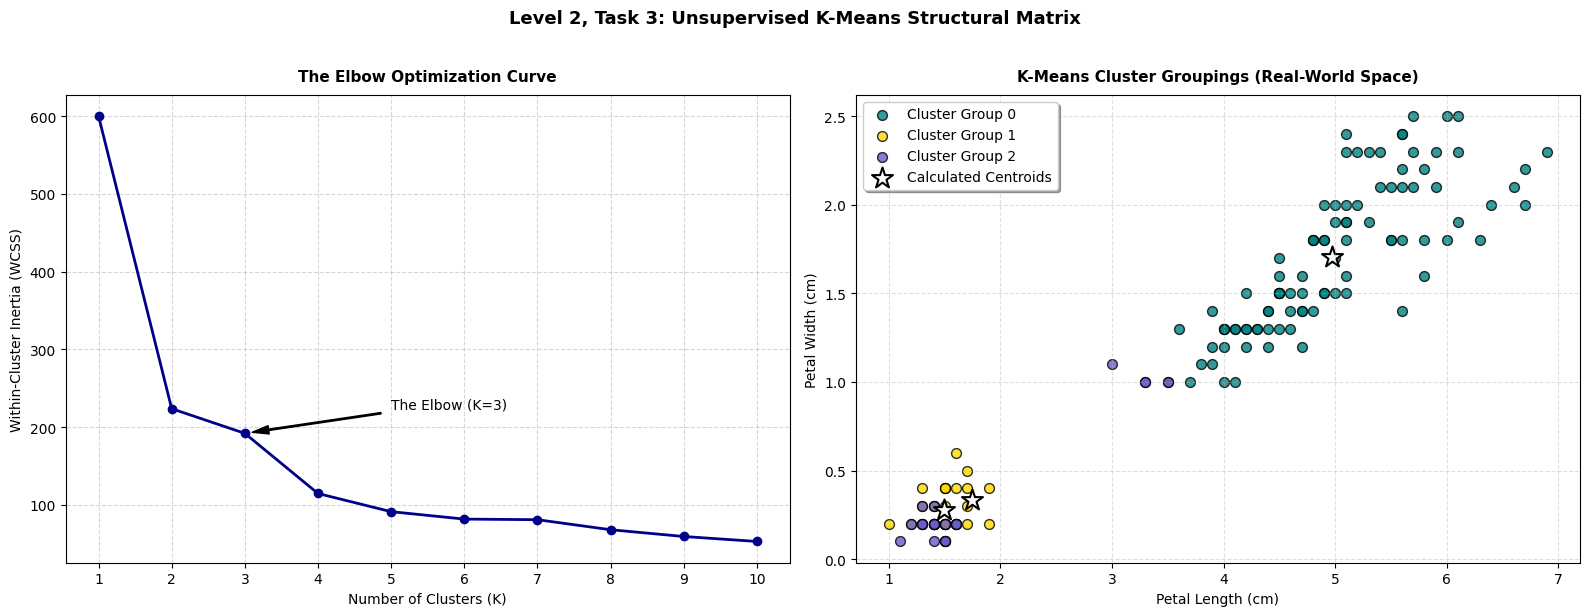


✔️ Unsupervised execution complete! Check your active graphics display panel.


In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# =====================================================================
# 1. DATA INGESTION & UNLABELING CLEANUP
# =====================================================================
filename = '1) iris.csv'

if not os.path.exists(filename):
    raise FileNotFoundError(
        f"Missing dataset file '{filename}' in directory '{os.getcwd()}'. "
        f"Please ensure it is uploaded to your environment."
    )

print(f"⏳ Loading target dataset: '{filename}'...")
df_iris = pd.read_csv(filename)

# PROFESSIONAL UN_SUPERVISED MANEUVER:
# Strip away the target label column entirely so the model has zero hints.
X_raw = df_iris.drop(columns=['species'])

# K-Means calculates geometric distances (Euclidean metric).
# We must scale features so variance in length doesn't drown out variance in width!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Convert back to a DataFrame for clean feature slicing later
X_scaled_df = pd.DataFrame(X_scaled, columns=X_raw.columns)

# =====================================================================
# 2. AUTOMATION SWEEP: THE ELBOW METHOD CHART
# =====================================================================
print("⚙️ Executing iterative cluster sweeps (K=1 to K=10) via Elbow Method...")
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    # n_init='auto' matches modern scikit-learn optimization defaults
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

# Create a side-by-side double dashboard plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Elbow Method Line Graph
ax1.plot(k_range, inertia_values, color='darkblue', marker='o', linestyle='-', linewidth=2)
ax1.set_title('The Elbow Optimization Curve', fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Within-Cluster Inertia (WCSS)')
ax1.set_xticks(k_range)
ax1.grid(True, linestyle='--', alpha=0.5)

# Highlight where the curve dramatically breaks/bends
ax1.annotate('The Elbow (K=3)', xy=(3, inertia_values[2]), xytext=(5, inertia_values[1]),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

# =====================================================================
# 3. TRAINING THE OPTIMAL MODEL (K = 3)
# =====================================================================
print("🎯 Training final K-Means architecture targeting K=3 groupings...")
optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')

# Predict cluster memberships (labels will be purely numeric: 0, 1, or 2)
cluster_assignments = final_kmeans.fit_transform(X_scaled)
df_iris['Cluster_ID'] = final_kmeans.labels_

# Extract calculated multi-dimensional cluster centers (Centroids)
centroids_scaled = final_kmeans.cluster_centers_

# Un-scale centroids back to real-world measurements for accurate chart coordinates
centroids_real = scaler.inverse_transform(centroids_scaled)

# =====================================================================
# 4. FINAL CLUSTER BOUNDARY VISUALIZATION
# =====================================================================
print("📊 Mapping spatial clusters and center coordinates onto scatter grid...")

# Select real-world features for explicit plotting: petal_length (idx 2) vs petal_width (idx 3)
colors = ['teal', 'gold', 'slateblue']

for cluster_num, color in enumerate(colors):
    # Slice rows assigned to this specific cluster index
    cluster_mask = df_iris['Cluster_ID'] == cluster_num
    ax2.scatter(
        df_iris.loc[cluster_mask, 'petal_length'],
        df_iris.loc[cluster_mask, 'petal_width'],
        c=color, label=f'Cluster Group {cluster_num}',
        edgecolors='k', alpha=0.8, s=50
    )

# Plot the real-world centroids as prominent white stars
ax2.scatter(
    centroids_real[:, 2], centroids_real[:, 3],
    color='white', marker='*', s=250, edgecolor='black',
    linewidth=1.5, label='Calculated Centroids'
)

ax2.set_title('K-Means Cluster Groupings (Real-World Space)', fontsize=11, fontweight='bold', pad=10)
ax2.set_xlabel('Petal Length (cm)', fontsize=10)
ax2.set_ylabel('Petal Width (cm)', fontsize=10)
ax2.legend(loc='upper left', frameon=True, shadow=True)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Level 2, Task 3: Unsupervised K-Means Structural Matrix", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✔️ Unsupervised execution complete! Check your active graphics display panel.")